In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

## Import dataset

In [2]:
df = pd.read_csv("../dataset/wine_quality_red_white.csv")

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [8]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

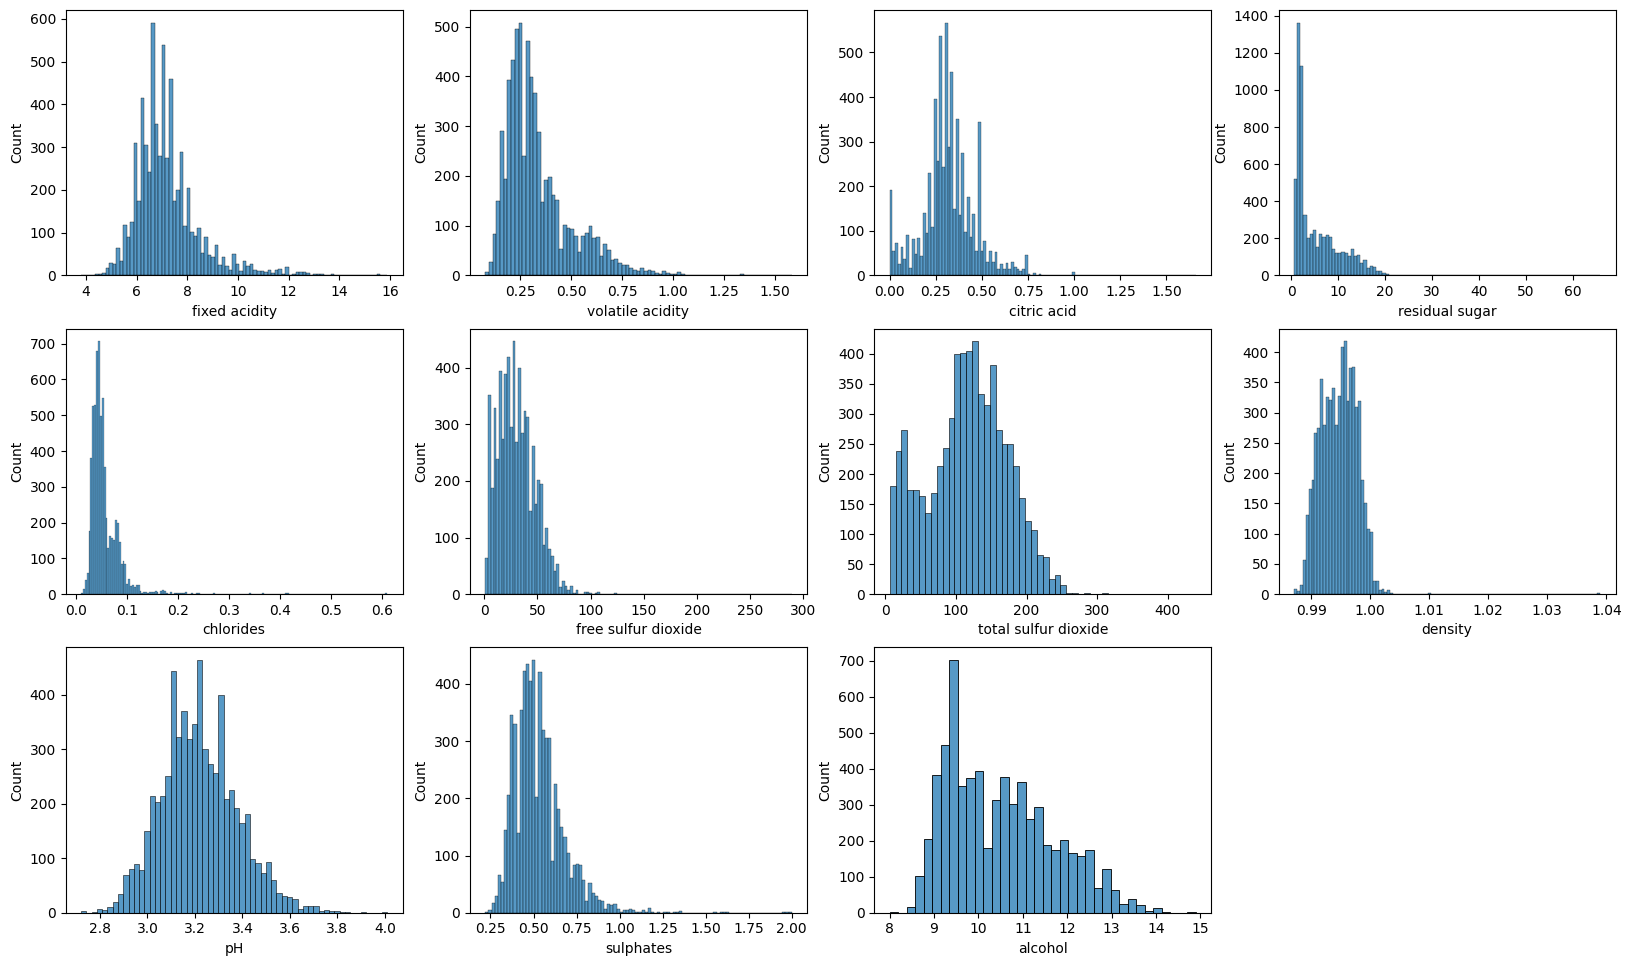

In [24]:
plt.figure(figsize=(20,20))
num_cols = df.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=df[num_cols[i]])


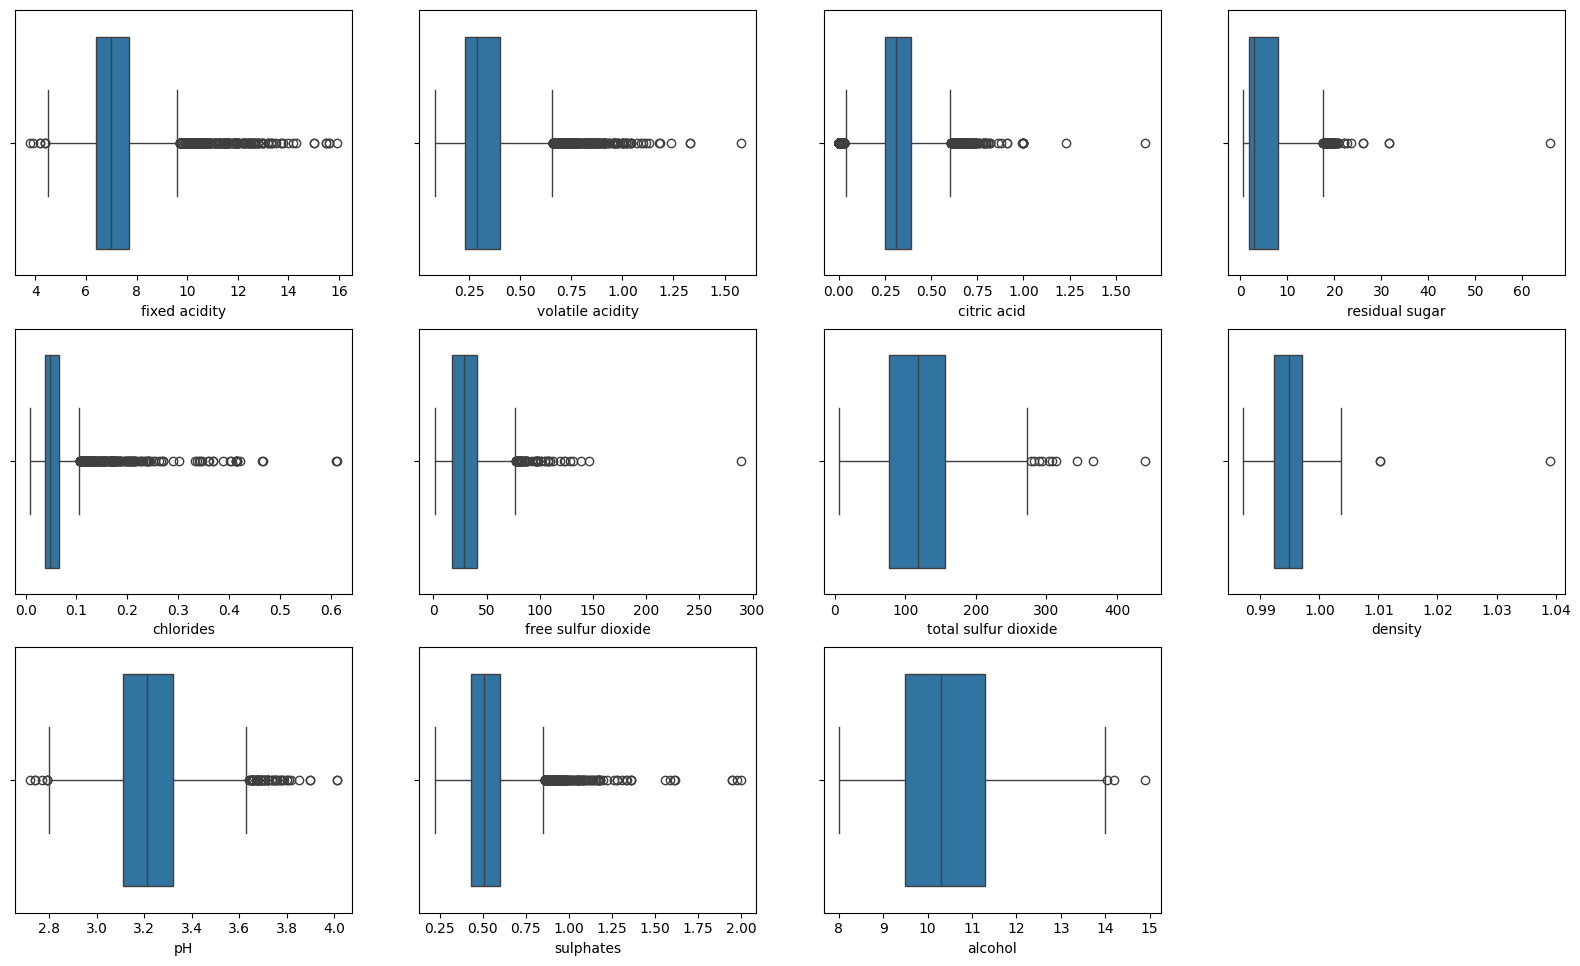

In [26]:
plt.figure(figsize=(20,20))
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.boxplot(x=df[num_cols[i]])

## Feature Engineering 

In [53]:
pt = PowerTransformer(method='yeo-johnson')

df_transformed = df.copy()

cols_to_transform = [col for col in num_cols if col != "density"]

df_transformed[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

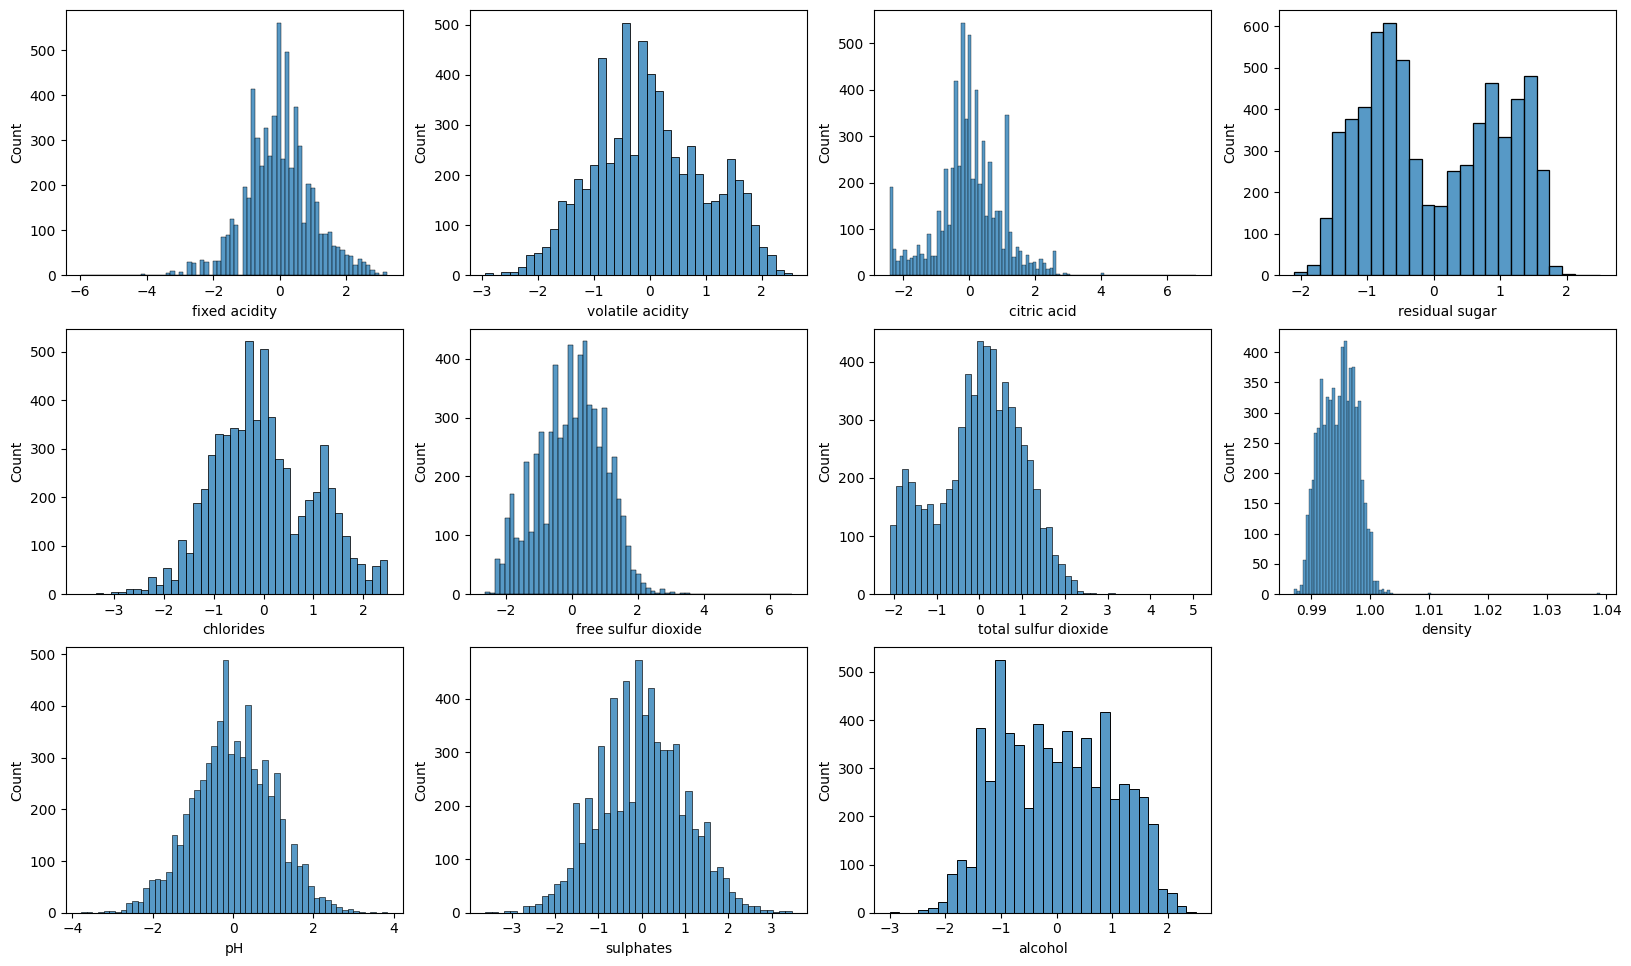

In [42]:
plt.figure(figsize=(20,20))
num_cols = df_transformed.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=df_transformed[num_cols[i]])


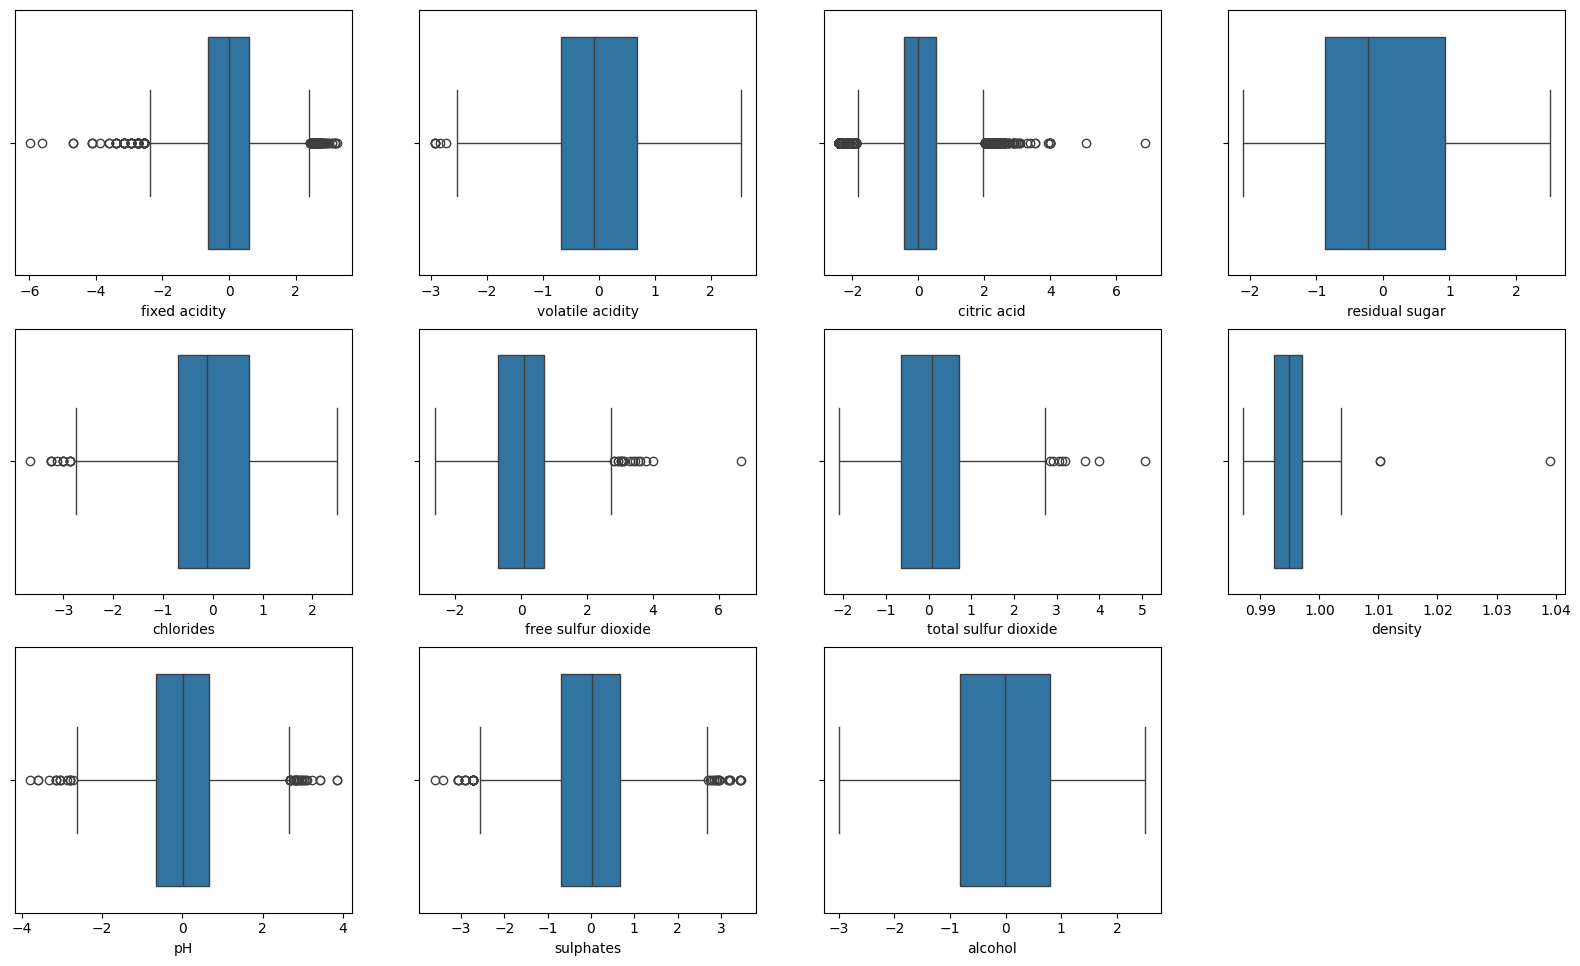

In [43]:
plt.figure(figsize=(20,20))
num_cols = df_transformed.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.boxplot(x=df_transformed[num_cols[i]])


In [63]:
dataframe = df_transformed[df_transformed["density"]<=1.01]
dataframe = dataframe[dataframe["chlorides"] > -3]
dataframe = dataframe[dataframe["fixed acidity"] > -4]
dataframe = dataframe[dataframe["free sulfur dioxide"] < 3]
dataframe = dataframe[dataframe["citric acid"] < 4]
dataframe = dataframe[dataframe["total sulfur dioxide"] < 3]
dataframe = dataframe[dataframe["quality"] != 9]

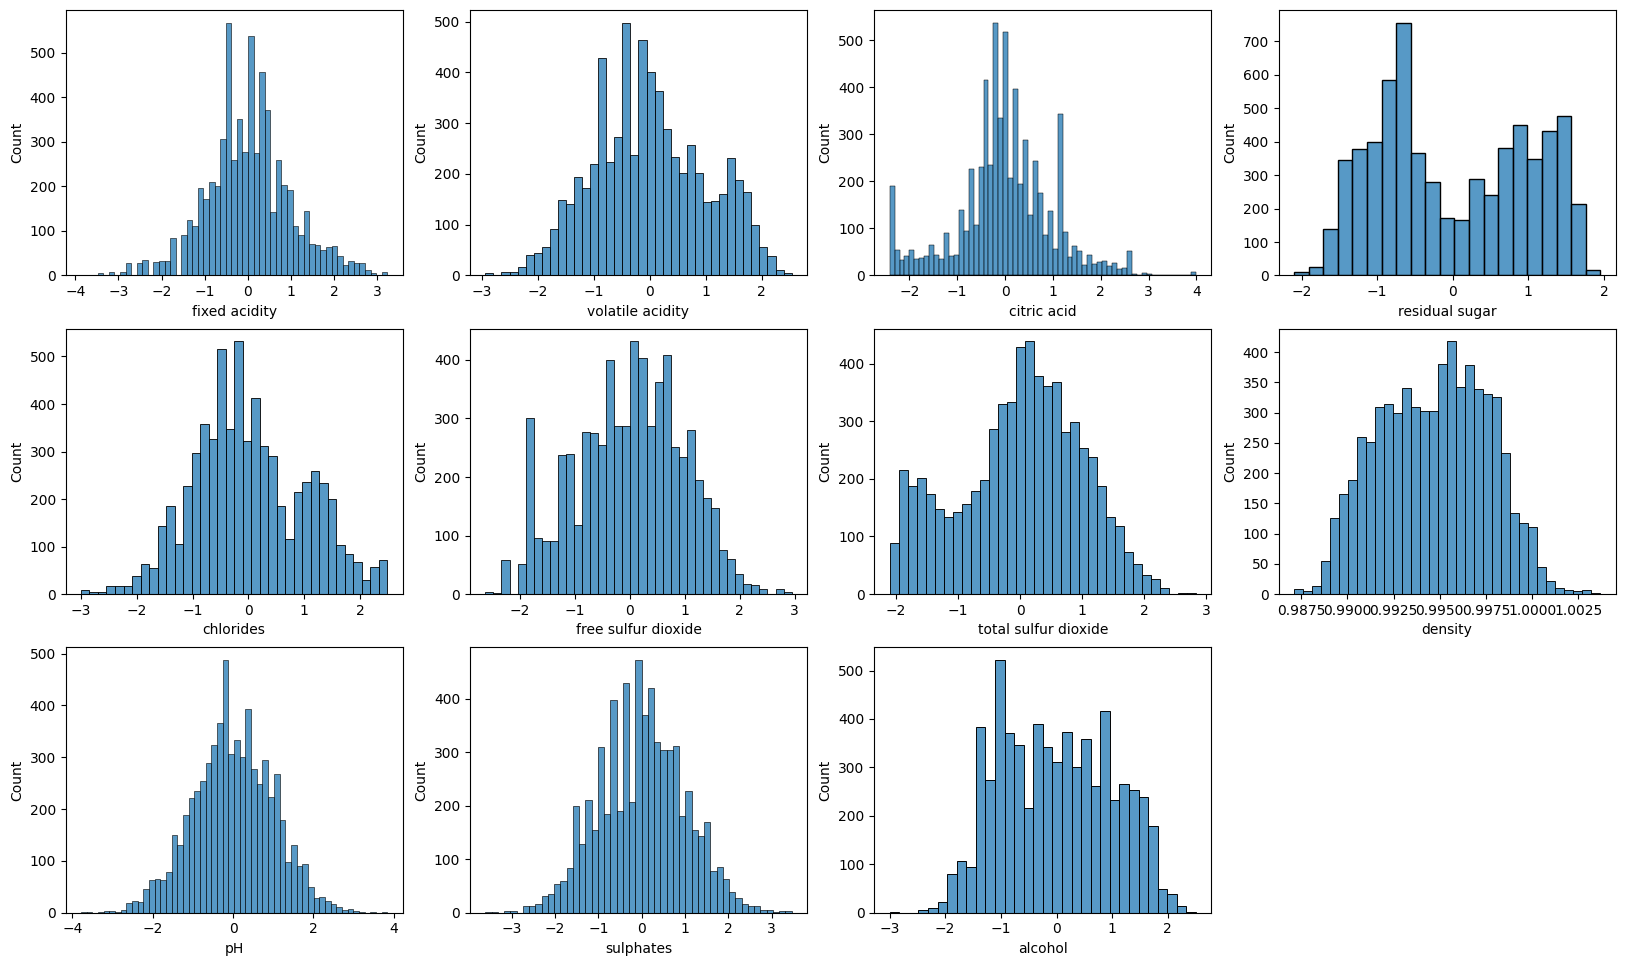

In [64]:
plt.figure(figsize=(20,20))
num_cols = dataframe.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=dataframe[num_cols[i]])


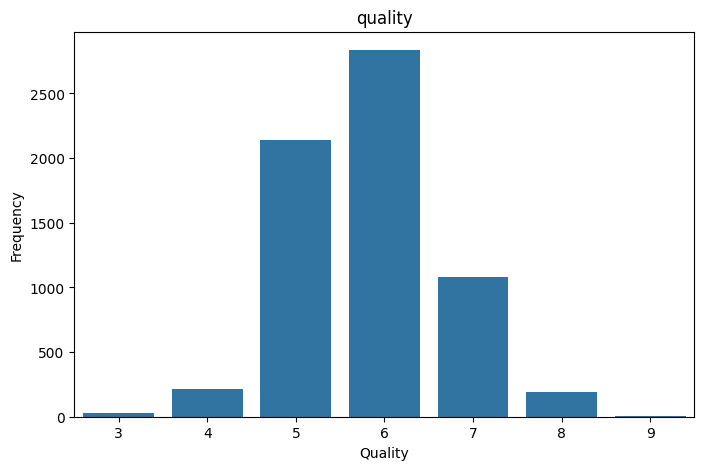

In [65]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["quality"])
plt.title("quality")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

## Multi-colinearity

Text(0.5, 1.0, 'Correlation Matrix')

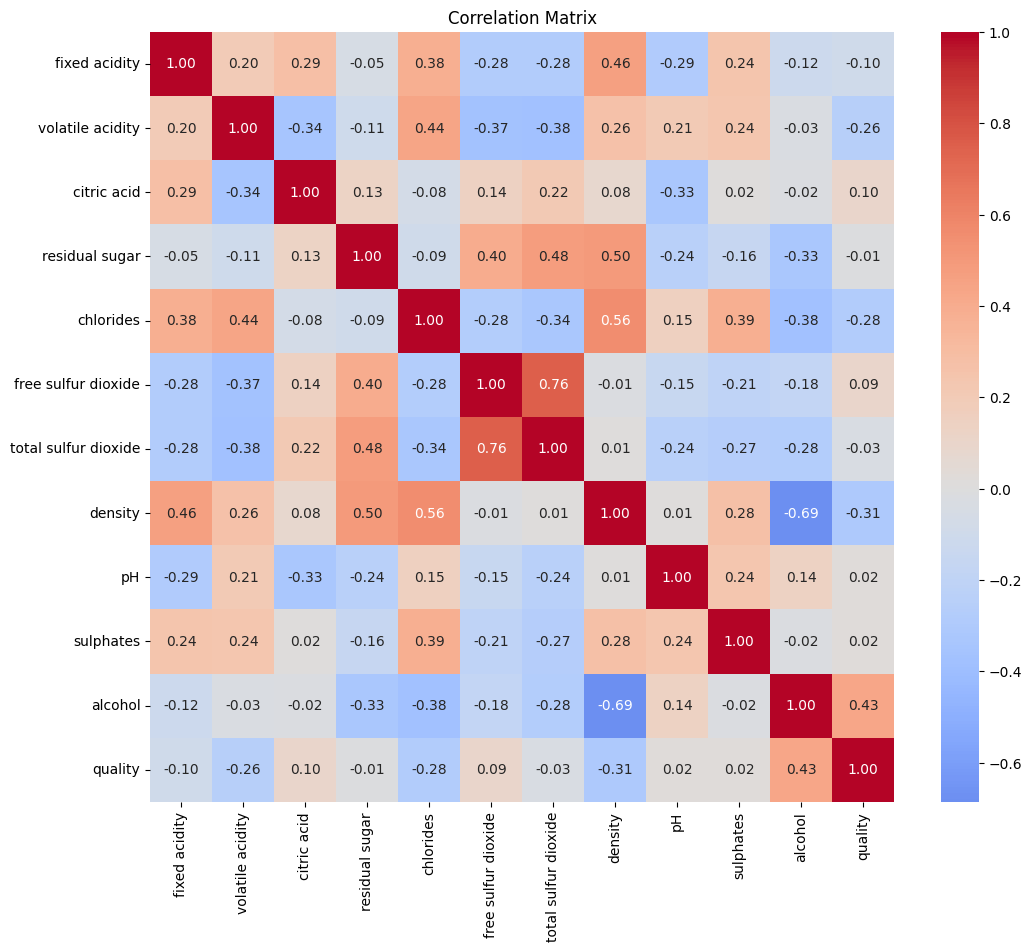

In [66]:
plt.figure(figsize=(12,10))
corr = df_transformed.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")

In [67]:
threshold = 0.8
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

high_corr

[]

In [ ]:
class DataCleaning():
    def __init__(self):
        pass

    def RemoveOutliers(df):
        df = df.copy()
        df = df[df["density"] <= 1.01]
        df = df[df["chlorides"] < 0.3]
        df = df[df["fixed acidity"] < 12]
        df = df[df["free sulfur dioxide"] < 100]
        df = df[df["citric acid"] < 0.75]
        df = df[df["total sulfur dioxide"] < 300]
        df = df[df["sulphates"] < 1.25]
        df = df[df["quality"] != 9]
        return df


    def split(self, dataframe, random_state=42, train_size=0.8, val_size=0.1):

        cols = [col for col in dataframe.columns if col != "quality"]
        X = dataframe[cols]
        y = dataframe["quality"]

        X_train, X_temp, y_train, y_temp = train_test_split(
            X,
            y,
            test_size=(1 - train_size),
            stratify=y,
            random_state=random_state
        )
        train_df = X_train.copy()
        train_df["quality"] = y_train

        train_df = self.RemoveOutliers(train_df)

        X_train = train_df.drop(columns=["quality"])
        y_train = train_df["quality"]

        X_val, X_test, y_val, y_test = train_test_split(
            X_temp,
            y_temp,
            test_size=0.5,
            stratify=y_temp,
            random_state=random_state
        )

        return X_train, X_val, X_test, y_train, y_val, y_test


In [91]:
df = pd.read_csv("../dataset/wine_quality_red_white.csv")
Cleaning = DataCleaning()
dataframe = DataCleaning.RemoveOutliers(df=df)

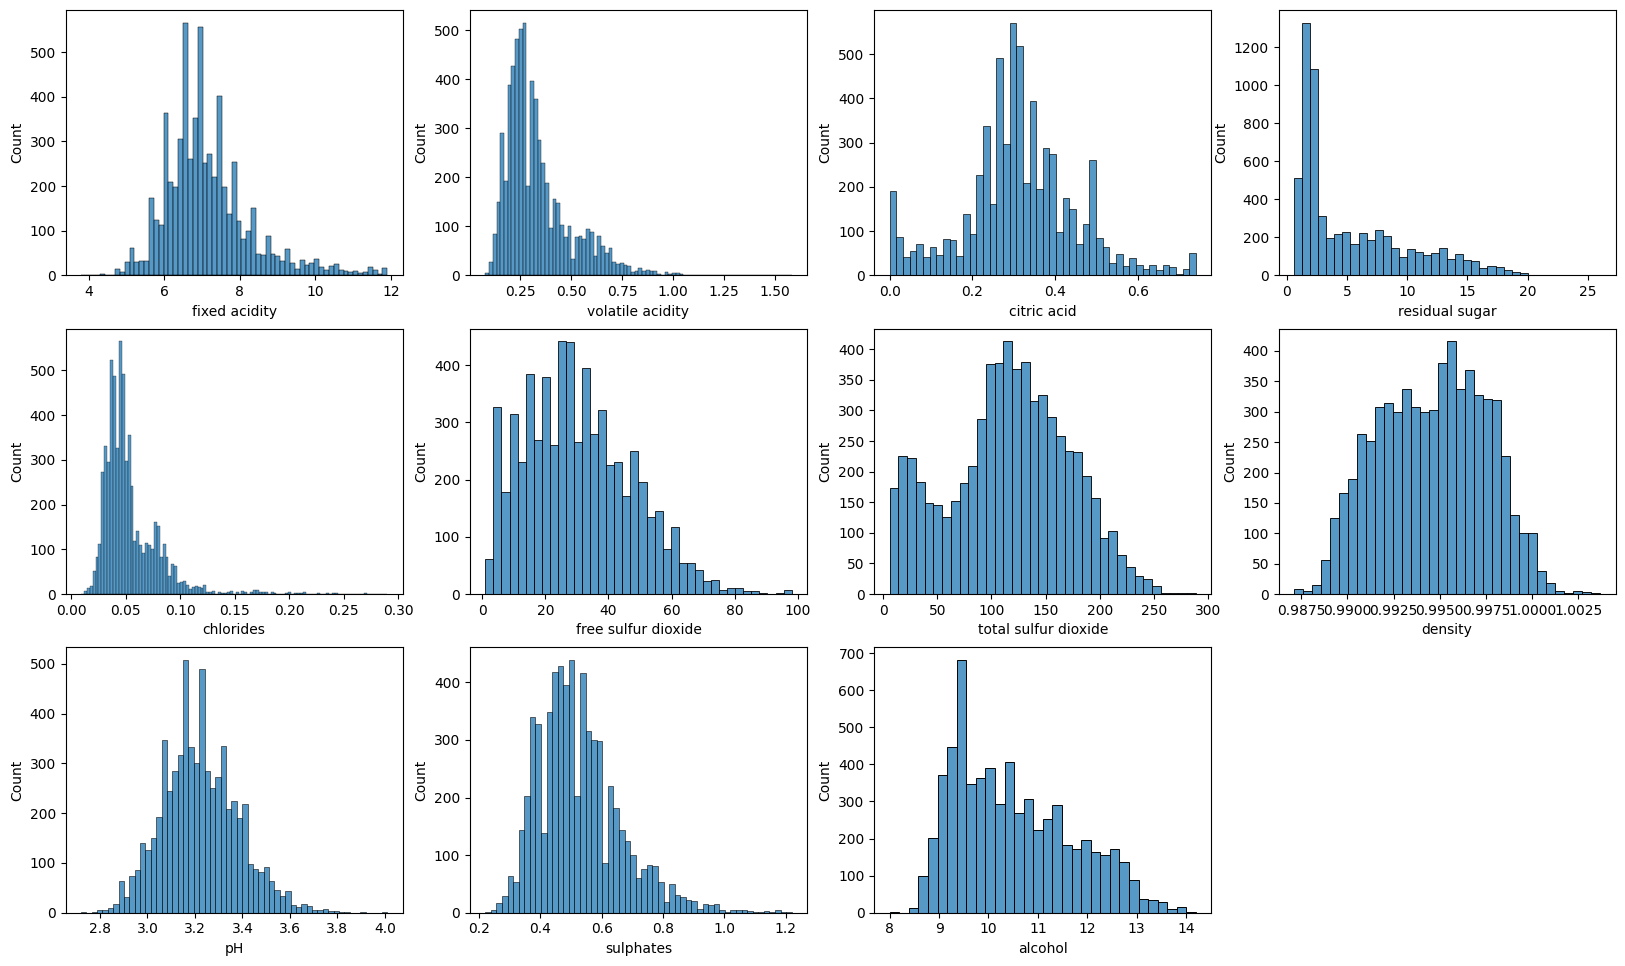

In [92]:
plt.figure(figsize=(20,20))
num_cols = dataframe.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=dataframe[num_cols[i]])


In [ ]:
pt = PowerTransformer(method='yeo-johnson')

df_transformed = df.copy()

cols_to_transform = [col for col in num_cols if col != "density"]

df_transformed[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

## Testing classification models

In [ ]:
cols_to_transform = [col for col in num_cols if col != "density"]

preprocessor = ColumnTransformer([
    ("power", PowerTransformer(method="yeo-johnson"), cols_to_transform)
], remainder="passthrough")

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])